# Analisis NLP de Reviews

En este notebook analizamos las reseñas de una empresa concreta y las comparamos con las de su competencia dentro del mismo sector.

Objetivos del proyecto:
- cargar y entender los datos
- aislar la empresa objetivo y su competencia
- limpiar el texto para poder analizarlo
- detectar temas principales con embeddings y clustering
- medir el sentimiento de las reseñas
- comparar resultados para extraer conclusiones


## 1. Carga de librerias y datos

Primero importamos las librerias necesarias y cargamos el dataset completo de Trustpilot.
La idea en este punto es entender qué columnas tenemos disponibles antes de filtrar la empresa a estudiar.


In [236]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import pipeline
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans
from bertopic import BERTopic
from sklearn.decomposition import PCA
from wordcloud import WordCloud
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

# Cargamos todas las librerias que usaremos en el analisis principal y en la parte exploratoria.
# Asi dejamos preparado el notebook para KMeans, visualizacion, WordCloud y BERTopic.
df = pd.read_csv("./data/trustpilot-reviews-123k.csv")

# Inspeccion inicial del dataset completo.
df.head()


,category,company,description,title,review,stars
0,Animals & Pets,ruffandtumbledogcoats.com,At Ruff and Tumble we are proud to be the mark...,Great quality dog drying robe although…,Great quality dog drying robe although had to ...,5
1,Animals & Pets,ruffandtumbledogcoats.com,At Ruff and Tumble we are proud to be the mark...,Really prompt service,"Really prompt service, The sofa covers have no...",5
2,Animals & Pets,ruffandtumbledogcoats.com,At Ruff and Tumble we are proud to be the mark...,Life saver,I’ve purchased first of those coats in May2020...,5
3,Animals & Pets,ruffandtumbledogcoats.com,At Ruff and Tumble we are proud to be the mark...,Brilliant coats,Brilliant coats. Really like the limited editi...,5
4,Animals & Pets,ruffandtumbledogcoats.com,At Ruff and Tumble we are proud to be the mark...,Great company and products,Great company and products. This is my 3rd dry...,5


## 2. Seleccion de la empresa objetivo

Aqu? definimos la empresa que queremos analizar y creamos un subconjunto solo con sus rese?as.
Esto nos permite centrar el estudio en un caso concreto antes de compararlo con el resto del mercado.


In [237]:
# Elegimos la empresa principal del analisis.
nombre_empresa = "www.sonicdirect.co.uk"

# Filtramos un dataframe solo con las reviews de esa empresa.
df_empresa = df[df["company"] == nombre_empresa].copy()

print(f"Dimensiones del dataset: {df_empresa.shape}")
df_empresa.head()


Dimensiones del dataset: (100, 6)


,category,company,description,title,review,stars
32160,Electronics & Technology,www.sonicdirect.co.uk,Sonic Direct has grown to become one of the UK...,Really impressed,"Really impressed, ordered on 27th Dec,wasn't e...",5
32161,Electronics & Technology,www.sonicdirect.co.uk,Sonic Direct has grown to become one of the UK...,"Great price, fantastic delivery",We purchased a tumble drier over the Christmas...,5
32162,Electronics & Technology,www.sonicdirect.co.uk,Sonic Direct has grown to become one of the UK...,Very efficient,"Easy to order, very quick delivery time even o...",5
32163,Electronics & Technology,www.sonicdirect.co.uk,Sonic Direct has grown to become one of the UK...,Our washing machine,Our washing machine broke down two days befor...,5
32164,Electronics & Technology,www.sonicdirect.co.uk,Sonic Direct has grown to become one of the UK...,"Well informed sales person, resulted in our pu...","The sales person was well informed, however, a...",5


In [238]:
# Identificamos el sector de la empresa para poder compararla con competidores similares.
sector = df_empresa["category"].iloc[0]
print(sector)


Electronics & Technology


## 3. Construccion del grupo de competencia

Una vez conocido el sector, extraemos todas las reviews de otras empresas de la misma categor?a.
As? conseguimos una referencia realista para comparar sentimiento, temas y valoraciones.


In [239]:
# Seleccionamos empresas del mismo sector, excluyendo la empresa objetivo.
df_competencia = df[
    (df["category"] == sector) &
    (df["company"] != nombre_empresa)
].copy()

print(f"Dimensiones del dataset de la competencia: {df_competencia.shape}")
df_competencia.head()


Dimensiones del dataset de la competencia: (5496, 6)


,category,company,description,title,review,stars
29662,Electronics & Technology,www.richersounds.com,Richer Sounds is a British home entertainment ...,Dave 55,Excellent service as always shout out to Jerom...,5
29663,Electronics & Technology,www.richersounds.com,Richer Sounds is a British home entertainment ...,Great service from Richer Sounds…,Great service from the Richer Sounds team at S...,5
29664,Electronics & Technology,www.richersounds.com,Richer Sounds is a British home entertainment ...,Wanted a TV for an 84 year old relative…,Wanted a TV for an 84 year old relative who’s ...,5
29665,Electronics & Technology,www.richersounds.com,Richer Sounds is a British home entertainment ...,IMFORMED FRIENDLY HELP FROM RICHER SOUNDS,Excellent rapport and helpfulness with your So...,5
29666,Electronics & Technology,www.richersounds.com,Richer Sounds is a British home entertainment ...,Purchase of Hi-Fi Equipment From Richer Sounds,"The Sales Assistant, Richard, was very helpful...",5


In [240]:
# Comprobacion rapida: la empresa objetivo no debe aparecer dentro del bloque de competencia.
df_competencia[df_competencia["company"] == "www.sonicdirect.co.uk"].shape


(0, 6)

In [241]:
# Revisamos el tamano de ambos conjuntos y cuantas empresas distintas forman la competencia.
print("Empresa:", df_empresa.shape)
print("Competencia:", df_competencia.shape)

df_competencia["company"].nunique()


Empresa: (100, 6)
Competencia: (5496, 6)


68

In [242]:
# ¿Hay URLs?
print("URLs:", df['review'].str.contains(r'http|www', na=False).sum())

# ¿Hay emojis?
print("Emojis:", df['review'].str.contains(r'[^\x00-\x7F]', na=False).sum())

# ¿Hay saltos de línea?
print("Saltos de línea:", df['review'].str.contains(r'\n', na=False).sum())

# ¿Hay hashtags?
print("Hashtags:", df['review'].str.contains(r'#\w+', na=False).sum())

# ¿Hay números?
print("Números:", df['review'].str.contains(r'\d', na=False).sum())

URLs: 16
Emojis: 34074
Saltos de línea: 0
Hashtags: 187
Números: 50327


## 4. Limpieza y preparacion del texto

Antes de aplicar modelos NLP conviene normalizar el texto.
En este caso pasamos todo a min?sculas, eliminamos s?mbolos y unificamos espacios para trabajar con un formato m?s consistente.


In [289]:
df_empresa = df_empresa.reset_index(drop=True)
df_empresa["review_id"] = df_empresa.index

df_competencia = df_competencia.reset_index(drop=True)
df_competencia["review_id"] = df_competencia.index

In [243]:
def limpiar_texto(texto):
    # Pasamos a minusculas para evitar duplicidades por capitalizacion.
    texto = texto.lower()
    
    # Eliminamos simbolos y numeros para quedarnos con palabras limpias.
    texto = re.sub(r"[^a-zA-Z\s]", "", texto)
    
    # Compactamos espacios repetidos.
    texto = re.sub(r"\s+", " ", texto).strip()
    return texto


In [244]:
# Unimos titulo y review porque ambos aportan informacion semantica.
df_empresa["text"] = (df_empresa["title"] + " " + df_empresa["review"]).apply(limpiar_texto)

df_competencia["text"] = (df_competencia["title"] + " " + df_competencia["review"]).apply(limpiar_texto)


## 5. Embeddings y descubrimiento de temas en la empresa

Transformamos cada review en un vector numérico con un modelo de `SentenceTransformers`.
Despu?s agrupamos esas reviews con `KMeans` para encontrar bloques tem?ticos parecidos.


In [245]:
# Cargamos un modelo ligero de embeddings para representar semanticamente cada review.
model = SentenceTransformer('all-MiniLM-L6-v2')

# Convertimos los textos de la empresa en vectores numericos.
embeddings_empresa = model.encode(df_empresa["text"].tolist(), show_progress_bar=True)


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1271.10it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 4/4 [00:01<00:00,  3.19it/s]


In [246]:
# Agrupamos las reviews en 5 clusters tematicos.
kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(embeddings_empresa)

# Guardamos el tema asignado a cada review.
df_empresa["topic"] = clusters


In [247]:
# Inspeccionamos ejemplos de cada cluster para interpretar manualmente de que habla cada tema.
for i in range(5):
    print(f"Topic {i} ")
    print("-" * 20)
    print(df_empresa[df_empresa["topic"] == i]["text"].head(5))

Topic 0 
--------------------
32164    well informed sales person resulted in our pur...
32168    great product excellent tv easy set up great p...
32190    tv very happy with the tv i have recently purc...
32197    the two men that delivered th the two men that...
32218    funny how the price on my sonyoled funny how t...
Name: text, dtype: str
Topic 1 
--------------------
32163    our washing machine our washing machine broke ...
32182    i had problems but they were all resolved the ...
32183    good mistakes made but sorted staff friendly s...
32186    washer dryer delivery all good even despite th...
32187    chest freezer always willing to help good cust...
Name: text, dtype: str
Topic 2 
--------------------
32165    excellent delivery crew delivery guys sangdeep...
32169    first time using this company wont be the last...
32173    excellent service absolutely fantastic service...
32177    always helpful friendly and always helpful fri...
32178    lovely guy who asked if i nee

In [248]:
# Vista rapida del dataframe ya enriquecido con la columna de topic.
df_empresa.head()


,category,company,description,title,review,stars,text,topic
32160,Electronics & Technology,www.sonicdirect.co.uk,Sonic Direct has grown to become one of the UK...,Really impressed,"Really impressed, ordered on 27th Dec,wasn't e...",5,really impressed really impressed ordered on t...,4
32161,Electronics & Technology,www.sonicdirect.co.uk,Sonic Direct has grown to become one of the UK...,"Great price, fantastic delivery",We purchased a tumble drier over the Christmas...,5,great price fantastic delivery we purchased a ...,3
32162,Electronics & Technology,www.sonicdirect.co.uk,Sonic Direct has grown to become one of the UK...,Very efficient,"Easy to order, very quick delivery time even o...",5,very efficient easy to order very quick delive...,4
32163,Electronics & Technology,www.sonicdirect.co.uk,Sonic Direct has grown to become one of the UK...,Our washing machine,Our washing machine broke down two days befor...,5,our washing machine our washing machine broke ...,1
32164,Electronics & Technology,www.sonicdirect.co.uk,Sonic Direct has grown to become one of the UK...,"Well informed sales person, resulted in our pu...","The sales person was well informed, however, a...",5,well informed sales person resulted in our pur...,0


### 5.1 Visualizacion rapida de los clusters

Antes de pasar al sentimiento, proyectamos los embeddings en 2 dimensiones con PCA.
Esta grafica no sirve para validar matematicamente los clusters, pero si para ver si existe cierta separacion visual entre grupos.


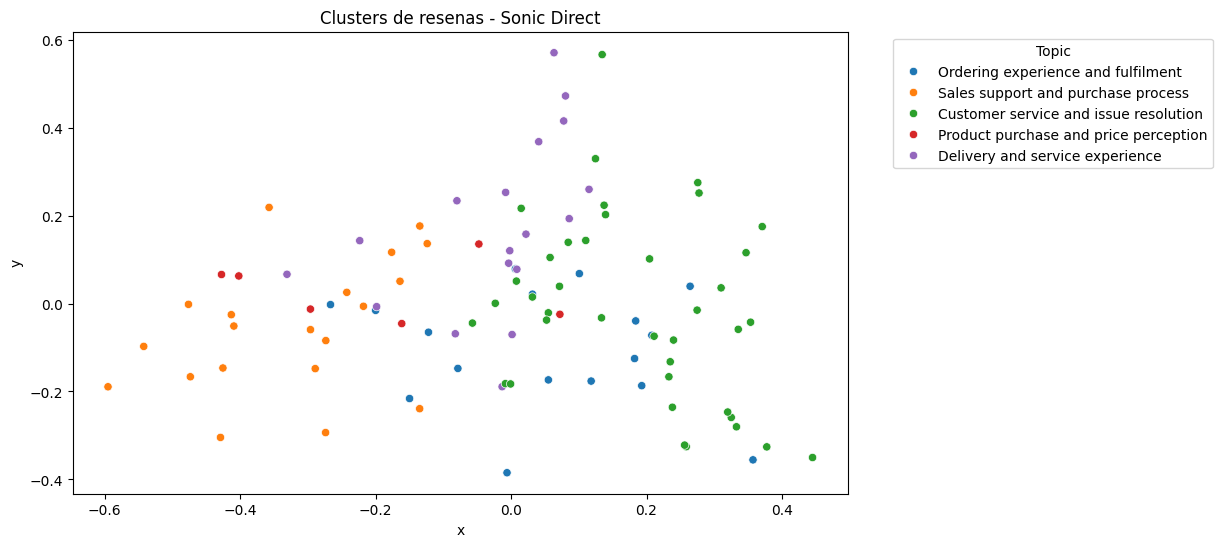

In [249]:
# Reducimos los embeddings a 2 dimensiones solo para poder visualizarlos.
pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(embeddings_empresa)

df_empresa["x"] = embeddings_2d[:, 0]
df_empresa["y"] = embeddings_2d[:, 1]

# Creamos una etiqueta legible para la grafica aunque el mapeo formal aparezca mas adelante.
mapa_topics_plot = {
    0: "Product purchase and price perception",
    1: "Customer service and issue resolution",
    2: "Delivery and service experience",
    3: "Sales support and purchase process",
    4: "Ordering experience and fulfilment"
}

df_empresa["topic_plot_name"] = df_empresa["topic"].map(mapa_topics_plot)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_empresa, x="x", y="y", hue="topic_plot_name", palette="tab10")
plt.title("Clusters de resenas - Sonic Direct")
plt.legend(title="Topic", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()


## 6. Analisis de sentimiento

En esta fase clasificamos cada review como positiva o negativa.
Adem?s guardamos la confianza del modelo para poder usarla si m?s adelante queremos profundizar en casos dudosos.


In [250]:
# Cargamos un modelo preentrenado de analisis de sentimiento.
sentiment_model = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english"
)


Loading weights: 100%|██████████| 104/104 [00:00<00:00, 919.87it/s]


In [251]:
def analizar_sentimiento(textos, batch_size=32):
    # Procesamos en lotes para ganar eficiencia en colecciones grandes de reviews.
    resultados = sentiment_model(textos, batch_size=batch_size, truncation=True)
    labels = [r["label"] for r in resultados]
    scores = [r["score"] for r in resultados]
    return labels, scores


In [252]:
# Aplicamos el modelo a la empresa objetivo.
labels_emp, scores_emp = analizar_sentimiento(df_empresa["text"].tolist())

df_empresa["sentiment"] = labels_emp
df_empresa["sentiment_score"] = scores_emp


In [253]:
# Repetimos el mismo proceso para la competencia y asi poder comparar despues.
labels_comp, scores_comp = analizar_sentimiento(df_competencia["text"].tolist())

df_competencia["sentiment"] = labels_comp
df_competencia["sentiment_score"] = scores_comp


## 7. Comparacion global de sentimiento

Calculamos el porcentaje de reviews positivas y negativas en ambos grupos.
Este bloque responde a una pregunta clave: la empresa analizada genera mejores sensaciones que su competencia o peores.


In [254]:
# Calculamos distribuciones porcentuales de sentimiento para que la comparacion sea justa.
sent_empresa = df_empresa["sentiment"].value_counts(normalize=True).mul(100).round(2)
sent_comp = df_competencia["sentiment"].value_counts(normalize=True).mul(100).round(2)

comparacion_sent = pd.DataFrame({
    "Sonic Direct": sent_empresa,
    "Competencia": sent_comp
}).fillna(0)

comparacion_sent


,Sonic Direct,Competencia
sentiment,,
NEGATIVE,71.0,69.56
POSITIVE,29.0,30.44


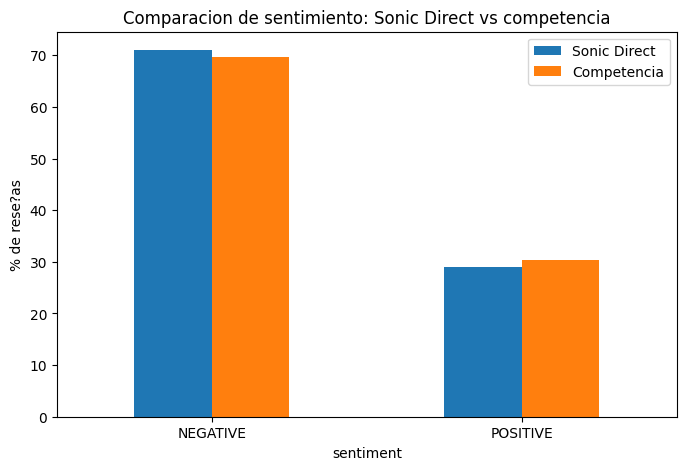

In [255]:
# Visualizamos la comparacion de forma mas intuitiva con un grafico de barras.
comparacion_sent.plot(kind="bar", figsize=(8, 5))
plt.title("Comparacion de sentimiento: Sonic Direct vs competencia")
plt.ylabel("% de rese?as")
plt.xticks(rotation=0)
plt.show()


> Nota de lectura de resultados:
>
> Este porcentaje de sentimiento refleja como clasifica el modelo el lenguaje de las reviews, no una tasa real de reputacion del negocio por si sola.
> Ademas, el modelo usado es binario (`POSITIVE` / `NEGATIVE`), asi que no contempla una clase neutra para resenas mixtas o tibias.


## 8. Temas en la competencia

Ahora descubrimos los temas principales dentro de la competencia usando el mismo enfoque.
Esto nos ayuda a ver si los problemas y fortalezas del sector coinciden con los de la empresa objetivo.


In [256]:
# Generamos embeddings para las reviews de la competencia.
embeddings_competencia = model.encode(df_competencia["text"].tolist(), show_progress_bar=True)

# Creamos clusters tematicos para el conjunto de competidores.
kmeans_comp = KMeans(n_clusters=5, random_state=42)
df_competencia["topic"] = kmeans_comp.fit_predict(embeddings_competencia)


Batches: 100%|██████████| 172/172 [00:49<00:00,  3.51it/s]


In [257]:
# Revisamos ejemplos de topics de la empresa para etiquetarlos manualmente con mas criterio.
for i in range(5):
    print(f"Topic empresa {i} ---")
    print(df_empresa[df_empresa["topic"] == i]["text"].head(5).to_string())


Topic empresa 0 ---
32164    well informed sales person resulted in our pur...
32168    great product excellent tv easy set up great p...
32190    tv very happy with the tv i have recently purc...
32197    the two men that delivered th the two men that...
32218    funny how the price on my sonyoled funny how t...
Topic empresa 1 ---
32163    our washing machine our washing machine broke ...
32182    i had problems but they were all resolved the ...
32183    good mistakes made but sorted staff friendly s...
32186    washer dryer delivery all good even despite th...
32187    chest freezer always willing to help good cust...
Topic empresa 2 ---
32165    excellent delivery crew delivery guys sangdeep...
32169    first time using this company wont be the last...
32173    excellent service absolutely fantastic service...
32177    always helpful friendly and always helpful fri...
32178    lovely guy who asked if i needed help lovely g...
Topic empresa 3 ---
32161    great price fantastic deli

In [258]:
# Hacemos lo mismo con la competencia para interpretar sus clusters.
for i in range(5):
    print(f"--- Topic competencia {i} ---")
    print(df_competencia[df_competencia["topic"] == i]["text"].head(5).to_string())


--- Topic competencia 0 ---
29664    wanted a tv for an year old relative wanted a ...
29699    wiim ultra the box is slightly damager but doe...
29712    they took the piss bought a turn table and spe...
29715    puzzled by having three staff members puzzled ...
29724    dry poor customer care dry poor customer care ...
--- Topic competencia 1 ---
29672    jonathan in your bristol store was jonathan in...
29681    fantastic service goods arrived very quickly i...
29686    saw the tv online called in the shop it saw th...
29689    rude person serving me update i just had a cal...
29691    richer sounds let down by delivery service bou...
--- Topic competencia 2 ---
29687    there had been a price for a device on there h...
29701    poor website especially payment my main issue ...
29710    awful customer service when things go wrong or...
29713    great company to deal with the customer update...
29721    we havnt received any one to set the tv we hav...
--- Topic competencia 3 ---
296

# Renombramos los clusters de Sonic Direct con etiquetas interpretables a partir de los ejemplos mostrados.
mapa_topics_empresa = {
    0: "Product purchase and price perception",
    1: "Customer service and issue resolution",
    2: "Delivery and service experience",
    3: "Sales support and purchase process",
    4: "Ordering experience and fulfilment"
}

df_empresa["topic_name"] = df_empresa["topic"].map(mapa_topics_empresa)


In [293]:
mapa_topics_empresa = {
    0: "Product purchase and price perception",
    1: "Customer service and issue resolution",
    2: "Delivery and service experience",
    3: "Sales support and purchase process",
    4: "Ordering experience and fulfilment"
}

df_empresa["topic_name"] = df_empresa["topic"].map(mapa_topics_empresa)

# Hacemos lo mismo para la competencia usando los ejemplos de cada cluster.
mapa_topics_comp = {
    0: "Customer complaints and incidents",
    1: "Store service and delivery coordination",
    2: "Website, payment and after-sales support",
    3: "Sales advice and positive store service",
    4: "Product-focused purchase experience"
}

df_competencia["topic_name"] = df_competencia["topic"].map(mapa_topics_comp)


In [294]:
# Tabla resumen para ver claramente que nombre corresponde a cada cluster de la empresa.
pd.DataFrame(
    sorted(mapa_topics_empresa.items()),
    columns=["topic", "topic_name"]
)


,topic,topic_name
0,0,Product purchase and price perception
1,1,Customer service and issue resolution
2,2,Delivery and service experience
3,3,Sales support and purchase process
4,4,Ordering experience and fulfilment


In [295]:
# Tabla resumen equivalente para la competencia.
pd.DataFrame(
    sorted(mapa_topics_comp.items()),
    columns=["topic", "topic_name"]
)


,topic,topic_name
0,0,Customer complaints and incidents
1,1,Store service and delivery coordination
2,2,"Website, payment and after-sales support"
3,3,Sales advice and positive store service
4,4,Product-focused purchase experience


In [296]:
# Creamos un mapeo equivalente para los clusters de la competencia.
mapa_topics_comp = {
    0: "Product and price",
    1: "Customer service",
    2: "Delivery",
    3: "Refunds and returns",
    4: "Product quality"
}

df_competencia["topic_name"] = df_competencia["topic"].map(mapa_topics_comp)


## 10. Sentimiento por topic

No solo importa el sentimiento global: tambi?n interesa saber en qu? temas aparecen m?s cr?ticas o m?s satisfacci?n.
Aqu? cruzamos topic y sentimiento para detectar puntos fuertes y puntos d?biles concretos.


In [297]:
# Calculamos la distribucion de sentimiento dentro de cada tema de la empresa.
sent_topic_empresa = (
    df_empresa.groupby(["topic_name", "sentiment"])
    .size()
    .unstack(fill_value=0)
)

sent_topic_empresa_pct = sent_topic_empresa.div(sent_topic_empresa.sum(axis=1), axis=0) * 100
sent_topic_empresa_pct.round(2)


sentiment,NEGATIVE,POSITIVE
topic_name,,
Customer service and issue resolution,92.31,7.69
Delivery and service experience,55.56,44.44
Ordering experience and fulfilment,58.82,41.18
Product purchase and price perception,83.33,16.67
Sales support and purchase process,50.00,50.00


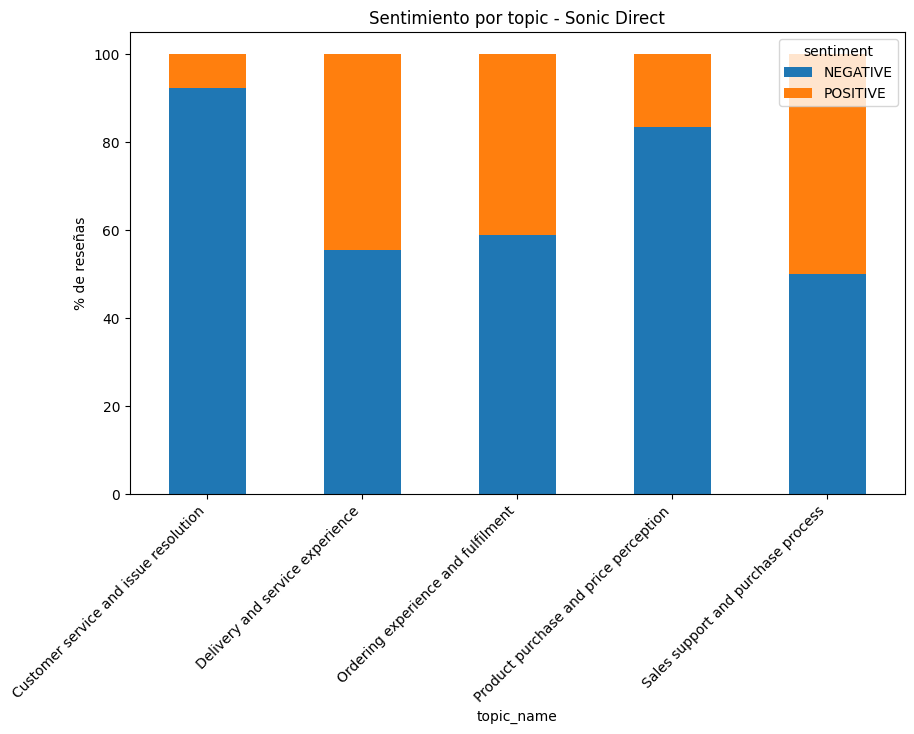

In [298]:
# Grafico apilado para ver de un vistazo que temas concentran mas opiniones negativas.
sent_topic_empresa_pct.plot(kind="bar", stacked=True, figsize=(10, 6))
plt.title("Sentimiento por topic - Sonic Direct")
plt.ylabel("% de reseñas")
plt.xticks(rotation=45, ha="right")
plt.show()


In [299]:
# Repetimos el analisis por topic para la competencia.
sent_topic_comp = (
    df_competencia.groupby(["topic_name", "sentiment"])
    .size()
    .unstack(fill_value=0)
)

sent_topic_comp_pct = sent_topic_comp.div(sent_topic_comp.sum(axis=1), axis=0) * 100
sent_topic_comp_pct.round(2)


sentiment,NEGATIVE,POSITIVE
topic_name,,
Customer service,86.38,13.62
Delivery,81.78,18.22
Product and price,74.65,25.35
Product quality,74.74,25.26
Refunds and returns,37.53,62.47


## 11. Relacion entre sentimiento, topics y estrellas

Terminamos conectando el NLP con la valoraci?n num?rica en estrellas.
Esto ayuda a comprobar si los temas detectados y el sentimiento predicho tienen coherencia con la puntuaci?n que deja el cliente.


In [300]:
# Media de estrellas por sentimiento en la empresa.
df_empresa.groupby("sentiment")["stars"].mean()


sentiment
NEGATIVE    2.408451
POSITIVE    4.448276
Name: stars, dtype: float64

In [301]:
# Media de estrellas por sentimiento en la competencia.
df_competencia.groupby("sentiment")["stars"].mean()


sentiment
NEGATIVE    2.597960
POSITIVE    4.496712
Name: stars, dtype: float64

In [312]:
# Media de estrellas por topic en la empresa para detectar areas mejor y peor valoradas.
df_empresa.groupby("topic_name")["stars"].mean().sort_values()


topic_name
Customer service and issue resolution    2.333333
Delivery and service experience          3.222222
Sales support and purchase process       3.300000
Product purchase and price perception    3.666667
Ordering experience and fulfilment       3.705882
Name: stars, dtype: float64

In [303]:
# Media de estrellas por topic en la competencia.
df_competencia.groupby("topic_name")["stars"].mean().sort_values()


topic_name
Customer service       2.663813
Delivery               2.767426
Product quality        3.069588
Product and price      3.125134
Refunds and returns    4.106324
Name: stars, dtype: float64

## 12. Exploracion lexica con WordCloud

Estas visualizaciones sirven para detectar palabras muy repetidas en las reviews de la empresa.
Son utiles como apoyo visual, aunque no sustituyen al analisis de sentimiento ni al modelado de topics.


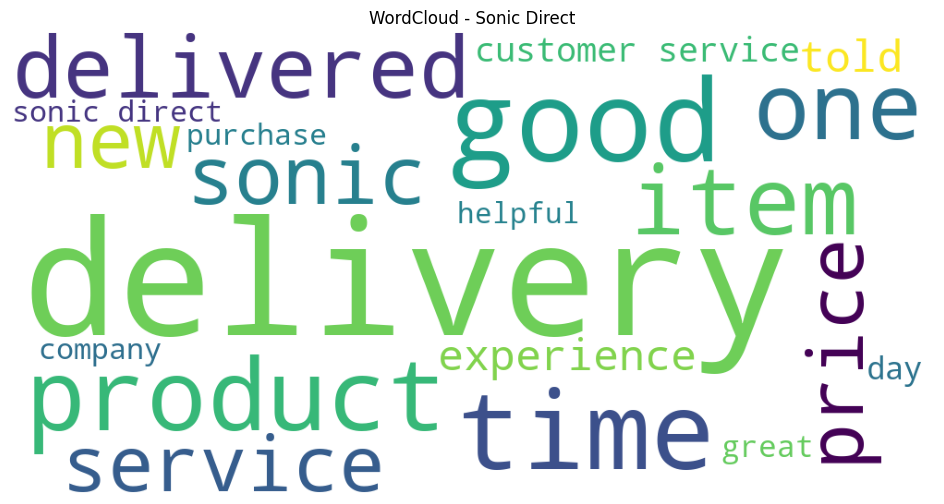

In [270]:
# Nube de palabras global de Sonic Direct.
texto_empresa = " ".join(df_empresa["text"])

wc = WordCloud(width=1000, height=500, background_color="white", max_words=20).generate(texto_empresa)

plt.figure(figsize=(12, 6))
plt.imshow(wc)
plt.axis("off")
plt.title("WordCloud - Sonic Direct")
plt.show()


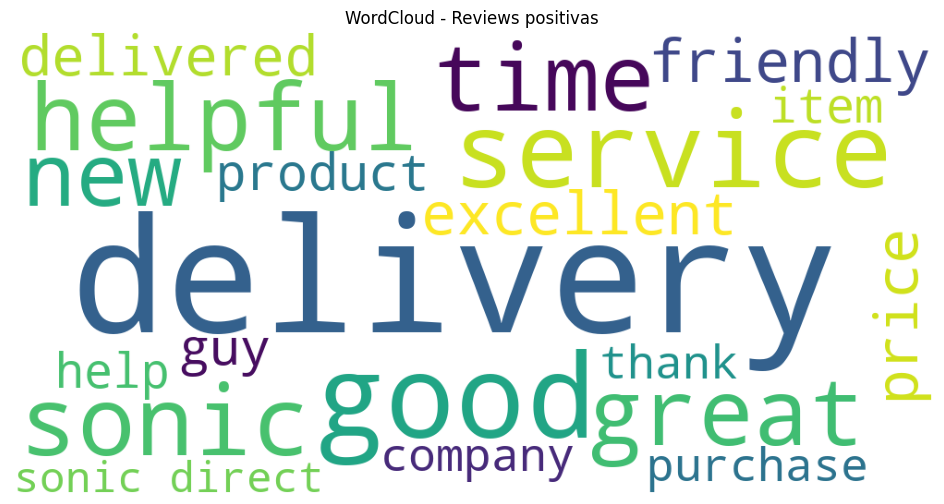

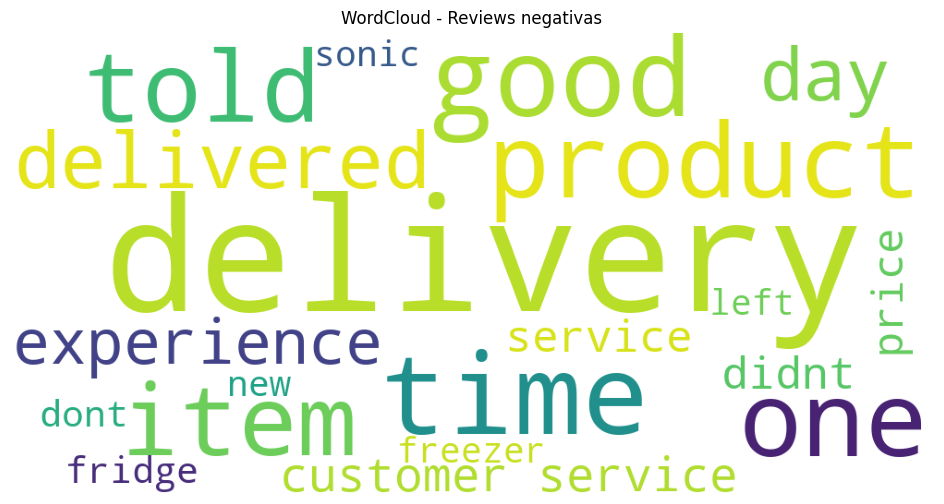

In [271]:
# Separamos el vocabulario de reviews positivas y negativas para comparar tonos y focos.
texto_pos = " ".join(df_empresa[df_empresa["sentiment"] == "POSITIVE"]["text"])
texto_neg = " ".join(df_empresa[df_empresa["sentiment"] == "NEGATIVE"]["text"])

wc_pos = WordCloud(width=1000, height=500, background_color="white", max_words=20).generate(texto_pos)
wc_neg = WordCloud(width=1000, height=500, background_color="white", max_words=20).generate(texto_neg)

plt.figure(figsize=(12, 6))
plt.imshow(wc_pos)
plt.axis("off")
plt.title("WordCloud - Reviews positivas")
plt.show()

plt.figure(figsize=(12, 6))
plt.imshow(wc_neg)
plt.axis("off")
plt.title("WordCloud - Reviews negativas")
plt.show()


## 13. Analisis alternativo con BERTopic

Despues del enfoque basado en embeddings + KMeans, aqui probamos un modelado de topics mas avanzado con BERTopic.
La idea no es sustituir automaticamente al bloque anterior, sino usarlo como contraste para ver si aparecen temas parecidos o mas interpretable.


In [272]:
# Eliminamos stopwords para ayudar a BERTopic a centrarse en palabras con mas contenido semantico.
stopwords = set(ENGLISH_STOP_WORDS)

def limpiar_texto_topics(texto):
    if not isinstance(texto, str):
        return ""
    
    texto = texto.lower()
    texto = re.sub(r'http\S+|www\.\S+', ' ', texto)      # URLs
    texto = re.sub(r'[^\x00-\x7F]+', ' ', texto)         # no ASCII / emojis
    texto = re.sub(r'#(\w+)', r'\1', texto)              # conservar palabra del hashtag
    texto = re.sub(r'\d+', ' ', texto)                   # números
    texto = re.sub(r'[^\w\s]', ' ', texto)               # puntuación
    texto = re.sub(r'_', ' ', texto)                     # guiones bajos
    texto = re.sub(r'\s+', ' ', texto).strip()           # espacios extra
    
    palabras = texto.split()
    palabras = [w for w in palabras if w not in stopwords and len(w) > 2]
    
    return " ".join(palabras)

df_empresa["text_topics"] = df_empresa["text"].apply(limpiar_texto_topics)


In [273]:
# Entrenamos BERTopic solo con las reviews de la empresa.
# Esto nos da topics mas flexibles, incluyendo un topic -1 para outliers o textos menos agrupables.
topic_model_emp = BERTopic(language="english", calculate_probabilities=True, verbose=True)
topics_emp, probs_emp = topic_model_emp.fit_transform(df_empresa["text_topics"].tolist())

df_empresa["bertopic_topic"] = topics_emp


2026-04-13 18:55:33,047 - BERTopic - Embedding - Transforming documents to embeddings.


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 3087.93it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 4/4 [00:00<00:00,  6.14it/s]
2026-04-13 18:55:36,997 - BERTopic - Embedding - Completed ✓
2026-04-13 18:55:36,998 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-13 18:55:37,199 - BERTopic - Dimensionality - Completed ✓
2026-04-13 18:55:37,201 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-13 18:55:37,209 - BERTopic - Cluster - Completed ✓
2026-04-13 18:55:37,214 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-13 18:55:37,229 - BERTopic - Representation - Completed ✓


In [274]:
# Resumen de topics detectados: tamano, nombre automatico y documentos representativos.
topic_model_emp.get_topic_info()


,Topic,Count,Name,Representation,Representative_Docs
0,-1,42,-1_delivery_good_service_item,"[delivery, good, service, item, product, custo...",[lacklustre experience lacklustre experience p...
1,0,39,0_delivery_machine_service_delivered,"[delivery, machine, service, delivered, time, ...",[good experience moment looked website extensi...
2,1,19,1_sonic_direct_product_price,"[sonic, direct, product, price, great, service...",[great price fantastic delivery purchased tumb...


In [275]:
# Palabras mas representativas del topic 0.
topic_model_emp.get_topic(0)


[('delivery', np.float64(0.10120832752775383)),
 ('machine', np.float64(0.04803498971405242)),
 ('service', np.float64(0.044597413309099165)),
 ('delivered', np.float64(0.041062014260506825)),
 ('time', np.float64(0.040732595003733114)),
 ('guys', np.float64(0.035113723459897495)),
 ('customer', np.float64(0.03191127667379826)),
 ('experience', np.float64(0.03180077238118975)),
 ('freezer', np.float64(0.03134087302290911)),
 ('fridge', np.float64(0.03134087302290911))]

In [276]:
# Grafico de barras con las palabras mas importantes por topic.
topic_model_emp.visualize_barchart()


In [277]:
# Jerarquia entre topics para ver si algunos grupos podrian fusionarse conceptualmente.
topic_model_emp.visualize_hierarchy()


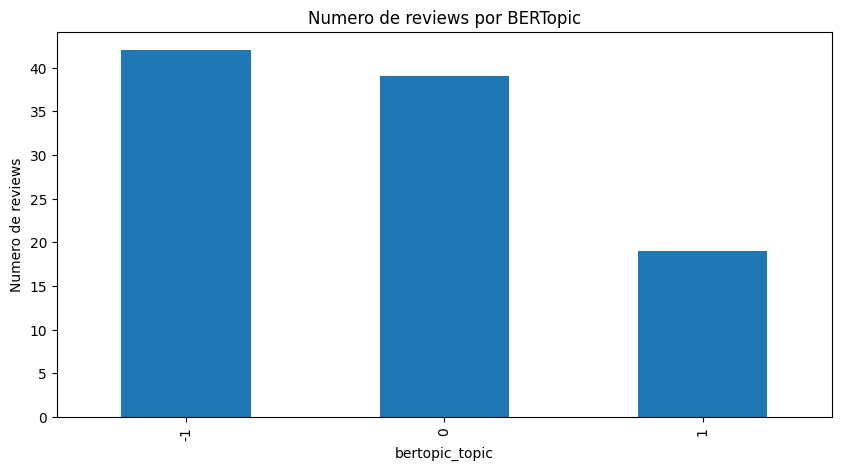

In [278]:
# Vemos cuantos documentos han caido en cada topic y lo representamos en un grafico.
df_empresa["bertopic_topic"].value_counts().sort_index()

df_empresa["bertopic_topic"].value_counts().sort_values(ascending=False).plot(
    kind="bar", figsize=(10, 5), title="Numero de reviews por BERTopic"
)
plt.ylabel("Numero de reviews")
plt.show()


In [279]:
# Cruzamos los topics de BERTopic con el sentimiento para detectar temas mas positivos o mas negativos.
bertopic_sent = (
    df_empresa.groupby(["bertopic_topic", "sentiment"])
    .size()
    .unstack(fill_value=0)
)

bertopic_sent


sentiment,NEGATIVE,POSITIVE
bertopic_topic,,
-1,32,10
0,31,8
1,8,11


In [280]:
# Pasamos los conteos a porcentaje para poder comparar topics con distinto volumen.
bertopic_sent_pct = bertopic_sent.div(bertopic_sent.sum(axis=1), axis=0) * 100
bertopic_sent_pct.round(2)


sentiment,NEGATIVE,POSITIVE
bertopic_topic,,
-1,76.19,23.81
0,79.49,20.51
1,42.11,57.89


### 13.2 Renombrado de topics de BERTopic

Una vez inspeccionadas las palabras clave y ejemplos reales, podemos traducir los IDs de BERTopic a etiquetas de negocio.
Esto hace mucho mas facil leer tablas, ejemplos y conclusiones sin depender de numeros abstractos.


In [281]:
# Etiquetas sugeridas a partir de las palabras clave y los ejemplos de cada topic.
mapa_bertopic_empresa = {
    -1: "Mixed or less consistent reviews",
    0: "Delivery, installation and service incidents",
    1: "Sales attention and product purchase experience"
}

df_empresa["bertopic_name"] = df_empresa["bertopic_topic"].map(mapa_bertopic_empresa)

df_empresa[["bertopic_topic", "bertopic_name"]].drop_duplicates().sort_values("bertopic_topic")


,bertopic_topic,bertopic_name
32164,-1,Mixed or less consistent reviews
32160,0,"Delivery, installation and service incidents"
32161,1,Sales attention and product purchase experience


In [305]:
# Rehacemos la tabla de sentimiento usando los nombres de topic en lugar de los IDs numericos.
bertopic_sent_named = (
    df_empresa.groupby(["bertopic_topic","bertopic_name", "sentiment"])
    .size()
    .unstack(fill_value=0)
)

bertopic_sent_named_pct = bertopic_sent_named.div(bertopic_sent_named.sum(axis=1), axis=0) * 100
bertopic_sent_named_pct.round(2)


,sentiment,NEGATIVE,POSITIVE
bertopic_topic,bertopic_name,,
-1,Mixed or less consistent reviews,76.19,23.81
0,"Delivery, installation and service incidents",79.49,20.51
1,Sales attention and product purchase experience,42.11,57.89


In [311]:
pd.set_option('display.max_colwidth', None)

df_empresa[df_empresa["sentiment"] == "NEGATIVE"][[
    "review_id", "title", "review", "text"
]]

,review_id,title,review,text
3,3,Our washing machine,Our washing machine broke down two days before Christmas. We did a price check from a number of suppliers for a new machine. Sonic was the most attractive. Ordered on line. The sales manager contacted me to confirm the order and informed me that I would receive a e mail that evening to inform us what time it would be delivered and in stalled the following day. The driver rang 30 mins before the scheduled time. Arrived installed and up and running within 24 hours from ordering. Brilliant service.,our washing machine our washing machine broke down two days before christmas we did a price check from a number of suppliers for a new machine sonic was the most attractive ordered on line the sales manager contacted me to confirm the order and informed me that i would receive a e mail that evening to inform us what time it would be delivered and in stalled the following day the driver rang mins before the scheduled time arrived installed and up and running within hours from ordering brilliant service
4,4,"Well informed sales person, resulted in our purchasing a 'variation' to what we expected to buy.","The sales person was well informed, however, a question to which the answer wasn't immediately available was researched through the excellent in store system to give the accurate response, rather than the all too often, 'I think'.It was also amusing to be led through the first aisle of the tvs to the pay station...my wife had deliberately led me straight to the vacuums, studiously avoiding any contact with tvs! I appreciated being able to browse them 'legitimately'",well informed sales person resulted in our purchasing a variation to what we expected to buy the sales person was well informed however a question to which the answer wasnt immediately available was researched through the excellent in store system to give the accurate response rather than the all too often i thinkit was also amusing to be led through the first aisle of the tvs to the pay stationmy wife had deliberately led me straight to the vacuums studiously avoiding any contact with tvs i appreciated being able to browse them legitimately
6,6,Lots of choice online and although i…,"Lots of choice online and although i was on the last minute still received the fridge/freezer in plenty time for getting a christmas shop in. The only problem was it is a bit too small but that was my own fault because i didn't check the size. Delivery guys was brilliant and kept in touch regarding time, would use Sonic direct again.",lots of choice online and although i lots of choice online and although i was on the last minute still received the fridgefreezer in plenty time for getting a christmas shop in the only problem was it is a bit too small but that was my own fault because i didnt check the size delivery guys was brilliant and kept in touch regarding time would use sonic direct again
22,22,"I had problems, but they were all resolved.","The website picture was misleading, and on delivery I was able to speak to the sales staff who agreed and the delivery was cancelled - all very efficiently. The delivery guys were polite and understanding. A delivery was then missed (friday evening!) and it did feel like someone had made up a story about trying to deliver, calling and putting something through my letterbox - as I had no calls, and have security cameras that would have picked them up (I was watching as I was waiting for the delivery). However, it was delivered a few days later and again the delivery staff were really polite and understanding. So there were a few issues, but it was all sorted effectively and efficiently. If it wasn't for the Friday night mess up, it would have been 5 stars.",i had problems but they were all resolved the website picture was misleading and on delivery i was able to speak to the sales staff who agreed and the delivery was cancelled all very efficiently the delivery guys were polite and understanding a deli

### 13.1 Lectura de los topics de BERTopic

En las siguientes celdas inspeccionamos palabras clave y ejemplos reales de reviews dentro de cada topic.
Esto ayuda a decidir si BERTopic esta separando mejor los temas de negocio que KMeans o si ambos cuentan una historia parecida.


In [283]:
# Comparamos las palabras mas representativas de los topics principales.
display(topic_model_emp.get_topic(0))
print("\n" + "="*50 + "\n")
topic_model_emp.get_topic(1)


[('delivery', np.float64(0.10120832752775383)),
 ('machine', np.float64(0.04803498971405242)),
 ('service', np.float64(0.044597413309099165)),
 ('delivered', np.float64(0.041062014260506825)),
 ('time', np.float64(0.040732595003733114)),
 ('guys', np.float64(0.035113723459897495)),
 ('customer', np.float64(0.03191127667379826)),
 ('experience', np.float64(0.03180077238118975)),
 ('freezer', np.float64(0.03134087302290911)),
 ('fridge', np.float64(0.03134087302290911))]

[('sonic', np.float64(0.1517291020395014)),
 ('direct', np.float64(0.08705150087705224)),
 ('product', np.float64(0.06734696190529912)),
 ('price', np.float64(0.05803433391803482)),
 ('great', np.float64(0.05078004217828047)),
 ('service', np.float64(0.05035244867021437)),
 ('delivery', np.float64(0.049910453686311834)),
 ('friendly', np.float64(0.04903255991609004)),
 ('warranty', np.float64(0.04688877145345135)),
 ('drier', np.float64(0.04688877145345135))]

In [ ]:
# Ejemplos reales del topic 0 para validar su interpretacion.
df_empresa[df_empresa["bertopic_topic"] == 0].columns


Index(['category', 'company', 'description', 'title', 'review', 'stars',
       'text', 'topic', 'x', 'y', 'topic_plot_name', 'sentiment',
       'sentiment_score', 'text_topics', 'bertopic_topic', 'bertopic_name'],
      dtype='str')

In [285]:
# Ejemplos reales del topic 1 para validar su interpretacion.
df_empresa[df_empresa["bertopic_topic"] == 1][["text", "sentiment"]].head(10)


,text,sentiment
32161,great price fantastic delivery we purchased a ...,POSITIVE
32168,great product excellent tv easy set up great p...,POSITIVE
32170,excellent service provided by sonic direct the...,POSITIVE
32171,amazing service everyone in sonic direct is we...,POSITIVE
32174,helpful and efficient our old tumbler stopped ...,POSITIVE
32175,sonic direct review salesman sqs was very know...,POSITIVE
32177,always helpful friendly and always helpful fri...,POSITIVE
32180,sonic were great sonic were great parcel force...,POSITIVE
32181,simple and effective i was very pleased that s...,POSITIVE
32189,i bought appliances from sonic for my i bought...,POSITIVE


In [286]:
# Ejemplos del topic -1, que BERTopic suele usar para outliers o textos menos homogeneos.
df_empresa[df_empresa["bertopic_topic"] == -1][["text", "sentiment"]].head(10)


,text,sentiment
32164,well informed sales person resulted in our pur...,NEGATIVE
32165,excellent delivery crew delivery guys sangdeep...,POSITIVE
32166,lots of choice online and although i lots of c...,NEGATIVE
32172,helpful service with my originallyordered micr...,POSITIVE
32176,kept in regular touch regarding kept in regula...,POSITIVE
32179,we spoke with staff members who clearly outlin...,POSITIVE
32184,fantastic company ordered my range cooker onli...,POSITIVE
32186,washer dryer delivery all good even despite th...,POSITIVE
32187,chest freezer always willing to help good cust...,POSITIVE
32188,love my new range cooker and cooker love my ne...,NEGATIVE


## 14. Conclusiones y validacion de outputs

Lo que muestran las salidas guardadas del notebook encaja razonablemente con el objetivo del proyecto, pero con varios matices importantes:

- El flujo general ahora si sigue una narrativa consistente: datos, empresa, competencia, limpieza, topics, sentimiento, comparacion, exploracion adicional y cierre.
- La comparacion global de sentimiento es internamente coherente con el resto del notebook, pero debe interpretarse como polaridad del lenguaje y no como reputacion real agregada.
- Las medias de estrellas por sentimiento cuadran bien con esa lectura: las reviews clasificadas como `POSITIVE` tienen mas estrellas que las `NEGATIVE` tanto en la empresa como en la competencia.
- El bloque mas util para insight de negocio en Sonic Direct es `Customer service and issue resolution`, porque aparece como el topic con peor mezcla de sentimiento en los outputs guardados.
- Los topics ya quedan renombrados con etiquetas legibles tanto en KMeans como en BERTopic para facilitar la interpretacion de negocio.
- Aun asi, algunos clusters de KMeans son algo mixtos y conviene leer ejemplos reales antes de sacar conclusiones demasiado cerradas.
- BERTopic refuerza la idea de que no todos los bloques tematicos se comportan igual: en los outputs guardados hay topics claramente mas negativos y otro bastante mas positivo.

Siguiente uso recomendado del notebook:
- usar KMeans para una lectura ejecutiva rapida
- usar BERTopic como contraste exploratorio
- cerrar con una celda final de insights de negocio y areas de mejora accionables
